# Topic modeling algorithms

We minimize topic modelling problem:
$$
\begin{align*}
& \underset{\Phi, \Phi}{\text{min}}
& & f(\Theta, \Phi) = -\sum_{d \in D} \sum_{w \in W} n_{dw} \ln{(\phi_{wt} \theta_{td})} + \frac{\tau}{2} \sum_{t \in T} \sum_{s \in T /\ t} \sum_{w \in W} \phi_{ws} \phi_{wt} \\
& \text{s.t.}
& & \sum_{w \in W} \phi_{wt} = 1, \phi_{wt} \geq 0 \\
& & & \sum_{w \in W} \theta_{wt} = 1, \theta_{wt} \geq 0
\end{align*} \quad \quad \quad (1)
$$
see "Rethinking Probabilistic Topic Modeling from the Point of View of Classical Non-Bayesian Regularization" Konstantin Vorontsov.

$\Theta \in \mathbb{R}^{|T| \times |W|}$ and $\Phi \in \mathbb{R}^{|D| \times |T|}$, where $|T|$ is a topic number (set manually by user), $|W|$ is a number of words in dictionary, $|D|$ is a number of documents (it is bag-of-words object, it may be web-page, text document or something else). Take a note that in both matrices all rows sums to 1, i.e. this is product of simplices.

As a regularizer we use "Decorrelation regularizer" (see И. А. Ирхин, К. В. Воронцов, Сходимость алгоритма аддитивной регуляризации тематических моделей, p.11):
$$
R(\Phi) = -\frac{\tau}{|T| (| T | - 1)} \sum_{t \neq s} \sum_{w \in W} \phi_{wt} \phi_{ws}
$$

We will compare the convergence rate of the EM-algorithm with following algorithms:
- Alternating column-wise FW Algorithm with descending step size.

Set step size
$$
\alpha_k = \min\left\{0.1,\; \frac{1}{k+1}\right\}.
$$

For each column $j$ in function derivative $G_\Theta^{(k)}$, solve the linear minimization oracle
$$
s_{\Theta,j}^{(k)} \in \arg\min_{s \in \mathcal{D}} 
\left\langle G_{\Theta,j}^{(k)},\, s \right\rangle,
$$
where
$$
S_\Theta^{(k)} = \bigl[ s_{\Theta,1}^{(k)}, \dots, s_{\Theta,m}^{(k)} \bigr].
$$

and form

$$
\Theta_{k+1}
= (1-\alpha_k)\Theta_k + \alpha_k S_\Theta^{(k)}.
$$

Then exactly the same step for $\Phi$ matrix variable.

- Alternating column-wise FW Algorithm with shortest step size and backtracking linesearch (see Vyguzov, A.A., Stonyakin, F.S. An Adaptive Variant of The Frank–Wolfe Method for Relative Smooth Convex Optimization Problems).

For each column $j$ in function derivative $G_\Theta^{(k)}$, solve the linear minimization oracle
$$
s_{\Theta,j}^{(k)} \in \arg\min_{s \in \mathcal{D}} 
\left\langle G_{\Theta,j}^{(k)},\, s \right\rangle,
$$
where
$$
S_\Theta^{(k)} = \bigl[ s_{\Theta,1}^{(k)}, \dots, s_{\Theta,m}^{(k)} \bigr].
$$

Let $L_{\Theta,k} = \bigl[ L_{\Theta,1}^{(k)}, \dots, L_{\Theta,m}^{(k)} \bigr]$ be an adaptively chosen smoothness parameter and $D$ is Bregman divergence, then calculate shortest step size for each column $j$:
$$
\alpha_{\Theta,k}^{(j)}
= \min\!\left\{1,\;
\frac{\langle G_\Theta^{(k)}, \Theta_k^{(j)} - s_{\Theta,j}^{(k)} \rangle}
{2 L_{\Theta,k}^{(j)}\, D(\Theta_k^{(j)}, s_{\Theta,j}^{(k)})}
\right\}.
$$

The update is
$$
\Theta_{k+1}
= (1-\alpha_{\Theta,k}) \Theta_k
+ \alpha_{\Theta,k} S_\Theta^{(k)}.
$$

Then exactly the same step for $\Phi$ matrix variable.

- Alternating Mirror Descent algortihm.
For each column $j$ in function derivative $G_\Theta^{(k)}$

$$\Theta^{k+1}_i = \frac{\Theta^k_i \exp\!\left(-\alpha_k G_{\Theta,j}^{(k)} \right)}{\sum_{j=1}^n X^k_{ij} \exp\!\left(-\alpha_k G_{\Theta,j}^{(k)}\right)},
\qquad i = 1,\dots,n.$$

Then by $\Phi$ in the same manner. $\alpha_k = \frac{\sqrt{2 D_{\max} \sigma}}{ \| G_{\Theta,j}^{(k)} \|_\infty \sqrt{N + 1}}$, where  $D_{\max}$ is maximum distance between starting point and any point in feasible set and $\sigma$ is strong convexity constant of Bregman divergence reference function (in our case this equals to 1) (see theoretical analyses in Beck, Amir. First-order methods in optimization. Society for Industrial and Applied Mathematics, 2017. p.260).

We use the next metrics:
- Perplexity (see https://docs.bigartm.org/en/stable/tutorials/scores_descr.html#perplexity), but withot exp and mean, just first term from (1).
- Top Tokens (see https://docs.bigartm.org/en/stable/tutorials/scores_descr.html#top-tokens), wee see at most probable token at the first five topics.

In [1]:
from __future__ import annotations
import time
import numpy as np
import scipy.sparse as sp
from scipy.sparse import coo_matrix
import pickle
import scipy.sparse as sp
import matplotlib.pyplot as plt
import os

Topic model (1) realization

In [2]:
class SmoothFunction:
    def __call__(self, x):
        assert 0, "SmoothFunction: __call__(x) is not defined"
        
    def gradient(self, x):
        assert 0, "SmoothFunction: gradient(x) is not defined"
 
    def func_grad(self, x, flag):
        """
        flag=0: function, flag=1: gradient, flag=2: function & gradient 
        """
        assert 0, "SmoothFunction: func_grad(x, flag) is not defined"

In [3]:
class Topic_modeling_loss(SmoothFunction):
    def __init__(self, X: sp.csr_matrix):
        self.X = X.tocsr()      # (D, W)

    def __call__(self, Phi: np.ndarray, Theta: np.ndarray) -> float:
        # Phi:   (W, T)
        # Theta: (T, D)
        num_docs, num_terms = self.X.shape
        eps = 1e-12
        loss = 0.0

        for d in range(num_docs):
            start, end = self.X.indptr[d], self.X.indptr[d+1]
            cols = self.X.indices[start:end]    # word indices
            vals = self.X.data[start:end]       # counts

            theta_d = Theta[:, d]               # (T,)
            phi_cols = Phi[cols, :]             # (K, T)

            pw = phi_cols @ theta_d             # (K,)
            pw = np.maximum(pw, eps)

            loss -= np.sum(vals * np.log(pw))

        return loss

    def gradient_by_theta(self, Phi, Theta):
        num_docs, num_terms = self.X.shape
        T = Theta.shape[0]
        grad_theta = np.zeros_like(Theta)
        eps = 1e-12

        for d in range(num_docs):
            start, end = self.X.indptr[d], self.X.indptr[d+1]
            cols = self.X.indices[start:end]
            vals = self.X.data[start:end]

            theta_d = Theta[:, d]          # (T,)
            phi_cols = Phi[cols, :]        # (K, T)

            pw = phi_cols @ theta_d        # (K,)
            pw = np.maximum(pw, eps)

            contrib = (phi_cols / pw[:, None]) * vals[:, None]   # (K,T)

            grad_theta[:, d] -= contrib.sum(axis=0)              # (T,)

        return grad_theta

    def gradient_by_phi(self, Phi, Theta):
        num_docs, num_terms = self.X.shape
        grad_phi = np.zeros_like(Phi)
        eps = 1e-12

        for d in range(num_docs):
            start, end = self.X.indptr[d], self.X.indptr[d+1]
            cols = self.X.indices[start:end]
            vals = self.X.data[start:end]

            theta_d = Theta[:, d]             # (T,)
            phi_cols = Phi[cols, :]           # (K, T)

            pw = phi_cols @ theta_d           # (K,)
            pw = np.maximum(pw, eps)

            # gradient wrt each φ(w,t)
            contrib = (vals / pw)[:, None] * theta_d[None, :]   # (K, T)

            grad_phi[cols, :] -= contrib

        return grad_phi

Regularizer implementation.

In [4]:
class Decorrelation_regularizer(SmoothFunction):
    def __init__(self, num_topics: int, tau: float = 1.0):
        self.num_topics = num_topics
        self.tau = tau

    def __call__(self, Phi: np.ndarray) -> float:
        # R(Phi) = τ / (T(T-1)) * sum_{t≠s} sum_w phi[w,t] phi[w,s]

        G = Phi @ Phi.T
        offdiag_sum = G.sum() - np.trace(G)  # sum_{t≠s} G_ts

        R_phi = self.tau / (self.num_topics * (self.num_topics - 1)) * offdiag_sum

        return R_phi
    
    def gradient(self, Phi: np.ndarray):
        # derivative w.r.t phi_uw: dR/dphi_uw = -2*alpha*(S_w - phi_uw), where S_w = sum_t phi_tw
        try:
            alpha = self.tau / (self.num_topics * (self.num_topics - 1.0))
            S_w = Phi.sum(axis=1)  # shape (W,)
            grad_phi = 2 * alpha * (S_w[:, None] - Phi)  # (W,T)
        except Exception:
            grad_phi = np.zeros_like(Phi, dtype=float)
        return grad_phi


    def func_grad(self, x, flag):
        if flag == 0:
            return self.__call__(x)
        elif flag == 1:
            return self.gradient(x)
        elif flag == 2:
            return self.__call__(x), self.gradient(x)
        else:
            assert 0, "Decorrelation_regularizer: func_grad(x, flag) invalid flag"

In [5]:
def EM_algorithm(X: sp.csr_matrix, Phi: np.ndarray, Theta: np.ndarray,
                 f_term: SmoothFunction, reg_term: SmoothFunction,
                 maxitrs=1000, verbskip=10, verbose=True, name="EM") -> tuple[np.ndarray, np.ndarray]:
    if verbose:
        print(f"\n{name} Algorithm")
        print("     k        F(x)        time")
    eps = 1e-12

    X = X.tocsr()
    num_docs, num_terms = X.shape
    _, num_topics = Phi.shape
    assert Phi.shape == (num_terms, num_topics)
    assert Theta.shape == (num_topics, num_docs)
    assert np.allclose(Phi.sum(axis=0), 1.0, atol=1e-8)
    assert np.allclose(Theta.sum(axis=0), 1.0, atol=1e-8)

    Phi = Phi.copy()
    Theta = Theta.copy()

    F_hist = []
    time_hist = []

    import time as _time
    t0 = _time.time()

    data_loss = f_term(Phi, Theta)
    try:
        reg_val = reg_term(Phi)
    except Exception:
        reg_val = 0.0
    # F = data_loss + reg_val
    F = data_loss
    F_hist.append(F)
    time_hist.append(0.0)  

    for k in range(maxitrs):
        iter_start = _time.time()

        n_wt = np.zeros_like(Phi, dtype=float)  # (W, T)
        n_td = np.zeros((num_topics, num_docs), dtype=float) # (T, D)

        for d in range(num_docs):
            start = X.indptr[d]
            end = X.indptr[d+1]
            if start == end:
                continue  # empty document
            cols = X.indices[start:end] # word indices in doc d
            vals = X.data[start:end].astype(float) # counts for those words

            Phi_sub_rows = Phi[cols, :] # (n, T) words in doc d
            Theta_sub_cols = Theta[:, d] # (T,) topic dist for doc d

            p_tw_for_d = Phi_sub_rows * Theta_sub_cols[np.newaxis, :] # here we started collect p_tdw for doc d
            p_tw_for_d /= np.maximum(p_tw_for_d.sum(axis=1), eps)[:, np.newaxis] 

            weighted = p_tw_for_d * vals[:, np.newaxis]
            
            for j, w in enumerate(cols):
                n_wt[w, :] += weighted[j, :]

            n_td[:, d] = weighted.sum(axis=0)

        grad_phi = reg_term.gradient(Phi)
        Phi_update = n_wt + Phi * grad_phi        # (W, T)
        Phi_update = np.maximum(Phi_update, eps)

        col_sums = Phi_update.sum(axis=0)         # (T,)
        for t in range(num_topics):
            # вероятность равна 0/0, поэтому, чтобы не было ошибки,
            # инициализируем любым распределением, все равно каким
            if col_sums[t] <= eps:
                Phi[:, t] = (np.ones(num_terms) / float(num_terms)) + eps
            else:
                Phi[:, t] = Phi_update[:, t] / col_sums[t]

        # ATTENTION!!! Градиент по Theta не реализован вообще! Если в регуляризаторе есть градиент по Theta, он не учитывается
        Theta_update = n_td.copy()
        col_sums = Theta_update.sum(axis=0)
        for d in range(num_docs):
            if col_sums[d] <= eps:
                Theta[:, d] = (np.ones(num_topics) / float(num_topics)) + eps
            else:
                Theta[:, d] = Theta_update[:, d] / col_sums[d]

        data_loss = f_term(Phi, Theta)
        try:
            reg_val = reg_term(Phi)
        except Exception:
            reg_val = 0.0
        # F = data_loss + reg_val
        F = data_loss

        F_hist.append(F)
        time_hist.append(_time.time() - t0)

        if verbose and (k % verbskip == 0 or k == maxitrs - 1):
            print(f"{k:6d}  {F:12.6e}  {time_hist[-1]:6.1f}")

        if k > 0:
            rel_change = abs(F_hist[-1] - F_hist[-2])
            if rel_change < 1e-9:
                if verbose:
                    print(f"converged (rel change {rel_change:.2e}) at iter {k}")
                break   
    
    return Phi, Theta, np.array(F_hist), np.array(time_hist)

In [6]:
def load_uci_bow(docword_path: str, vocab_path: str):
    with open(vocab_path, "r") as f:
        vocab = [line.strip() for line in f]

    with open(docword_path, "r") as f:
        num_docs = int(f.readline())
        num_terms = int(f.readline())
        num_nonzero = int(f.readline())

        rows = np.zeros(num_nonzero, dtype=np.int32)
        cols = np.zeros(num_nonzero, dtype=np.int32)
        data = np.zeros(num_nonzero, dtype=np.int32)

        for i, line in enumerate(f):
            doc_id, word_id, count = map(int, line.split())
            rows[i] = doc_id - 1 
            cols[i] = word_id - 1
            data[i] = count

    X = coo_matrix((data, (rows, cols)),
                   shape=(num_docs, num_terms),
                   dtype=np.int32).tocsr()

    return X, vocab

Divergences:

In [7]:
def kl_divergence(s, x, eps=1e-12):
    s_safe = np.clip(s, eps, None)
    x_safe = np.clip(x, eps, None)
    return np.sum(s_safe * (np.log(s_safe) - np.log(x_safe)) - s_safe + x_safe)


def bregman_itakura_saito(x, y, eps=1e-12):
    x_safe = np.clip(x, eps, None)
    y_safe = np.clip(y, eps, None)

    ratio = x_safe / y_safe
    return np.sum(-np.log(ratio) + ratio - 1.0)


def euklid_distance(x, y, eps=1e-12):
    return 1/2 * np.sum((x - y))

Frank-Wolfe step with backtracking linesearch

In [8]:
def fw_backtracking_step(current, grad, loss_fn, divergence, Phi, Theta,
                         lmo, L_init, name, gamma=2.0):
    L = L_init
    fx = loss_fn(Phi, Theta)

    S = np.column_stack([lmo(grad[:, j]) for j in range(grad.shape[1])])
    direction = S - current
    gaps_by_col = np.sum(grad * direction, axis=0)
    assert np.all(gaps_by_col <= 1e-12), f"{name}: non-descent FW direction"

    while True:
        divergence_vals = np.array([divergence(S[:, j], current[:, j]) for j in range(grad.shape[1])])
        alpha_by_row = np.minimum(1., -gaps_by_col / (2 * L * divergence_vals + 1e-12))
        
        new_x = current + alpha_by_row * direction

        if name == "Theta":
            f_new = loss_fn(Phi, new_x)
        else:
            f_new = loss_fn(new_x, Theta)

        rhs = fx + np.sum(alpha_by_row * gaps_by_col) + L * np.sum((alpha_by_row ** gamma) * divergence_vals)

        if f_new <= rhs:
            L /= 2.0
            break

        L *= 2.0

    return new_x, alpha_by_row, L, S

In [9]:
def lmo_simplex(radius=1):
    def lmo_f(g):
        s = np.zeros(g.shape)
        s += 1e-15
        min_indices = np.where(g == np.min(g))[0]
        s[min_indices[0]] = radius
        return s

    return lmo_f

In [10]:
def FW_topic_model_alternating(topic_model_loss, reg_f, divergence,
                               Phi0, Theta0, maxitrs, lmo,
                               epsilon=1e-14, verbose=True, verbskip=1, name="FW, Shortest Step"):

    if verbose:
        print(r"\nFW algorithm name={}".format(name))
        print("     k      F(x)         time")

    start_time = time.time()
    F_hist, T_hist = [], []

    Theta = np.copy(Theta0)
    Phi = np.copy(Phi0)

    fx = topic_model_loss(Phi, Theta)
    F_hist.append(fx)
    T_hist.append(time.time() - start_time)

    L_theta = 150.0
    L_phi = 150.0

    for k in range(maxitrs):

        # ---------------------- Θ STEP ----------------------
        f_grad_theta = topic_model_loss.gradient_by_theta(Phi, Theta)

        Theta, alpha_theta, L_theta, S_theta = fw_backtracking_step(
            current=Theta,
            grad=f_grad_theta,
            loss_fn=topic_model_loss,
            Phi=Phi, Theta=Theta,
            lmo=lmo, 
            divergence=divergence,
            L_init=L_theta,
            name="Theta"
        )

        # ---------------------- Φ STEP ----------------------
        f_grad_phi = topic_model_loss.gradient_by_phi(Phi, Theta)
        reg_grad_phi = reg_f.gradient(Phi)
        total_grad_phi = f_grad_phi + reg_grad_phi

        Phi, alpha_phi, L_phi, S_phi = fw_backtracking_step(
            current=Phi,
            grad=total_grad_phi,
            loss_fn=lambda P, Th: topic_model_loss(P, Th) + reg_f(P),
            Phi=Phi, Theta=Theta,
            lmo=lmo, 
            divergence=divergence,
            L_init=L_phi,
            name="Phi"
        )

        # ---------------------- Logging ----------------------
        fx = topic_model_loss(Phi, Theta)
        F_hist.append(fx)
        T_hist.append(time.time() - start_time)

        if verbose and (k % verbskip == 0 or k == 1):
            print(f"{k:6d}  {F_hist[k]:10.3e}  {T_hist[k]:6.1f}")

        if abs(F_hist[k] - F_hist[k - 1]) < epsilon:
            break

    return Phi, Theta, np.array(F_hist), np.array(T_hist)

In [11]:
def FW_desc_topic_model_alternating(topic_model_loss, reg_f, 
                               Phi0, Theta0, maxitrs, lmo, epsilon=1e-14, 
                               verbose=True, verbskip=1, name="FW, 2/(k+2)"):

    if verbose:
        print(r"\nFW algorithm name={}".format(name))
        print("     k      F(x)         time")

    start_time = time.time()
    F_hist, T_hist = [], []

    Theta = np.copy(Theta0)
    Phi = np.copy(Phi0)

    fx = topic_model_loss(Phi, Theta)
    F_hist.append(fx)
    T_hist.append(time.time() - start_time)

    for k in range(maxitrs):
        alpha_k = min(0.1, 1 / (k+1))

        # ---------------------- Θ STEP ----------------------
        f_grad_theta = topic_model_loss.gradient_by_theta(Phi, Theta)
        S_theta = np.column_stack([lmo(f_grad_theta[:, j]) for j in range(f_grad_theta.shape[1])])
        Theta = Theta + alpha_k * (S_theta - Theta)

        # ---------------------- Φ STEP ----------------------
        f_grad_phi = topic_model_loss.gradient_by_phi(Phi, Theta)
        reg_grad_phi = reg_f.gradient(Phi)
        total_grad_phi = f_grad_phi + reg_grad_phi
        S_phi = np.column_stack([lmo(total_grad_phi[:, j]) for j in range(total_grad_phi.shape[1])])
        Phi = Phi + alpha_k * (S_phi - Phi)

        # ---------------------- Logging ----------------------
        fx = topic_model_loss(Phi, Theta)
        F_hist.append(fx)
        T_hist.append(time.time() - start_time)

        if verbose and (k % verbskip == 0 or k == 1):
            print(f"{k:6d}  {F_hist[k]:10.3e}  {T_hist[k]:6.1f}")

        if abs(F_hist[k] - F_hist[k - 1]) < epsilon:
            break

    return Phi, Theta, np.array(F_hist), np.array(T_hist)

In [ ]:
def Mirror_descent_on_simplex(X: sp.csr_matrix, Phi0: np.ndarray, Theta0: np.ndarray,
                 topic_model_loss: SmoothFunction, reg_term: SmoothFunction,
                 maxitrs=1000, verbskip=10, epsilon=1e-14, verbose=True, name="") -> tuple[np.ndarray, np.ndarray]:
    if verbose:
        print(r"\nMirror descent on simplex, name={}".format(name))
        print("     k        F(x)        time")

    X = X.tocsr()
    
    F_hist = []
    time_hist = []

    import time as _time
    t0 = _time.time()

    Theta = np.copy(Theta0)
    Phi = np.copy(Phi0)
    data_loss = topic_model_loss(Phi, Theta)
    F_hist.append(data_loss)

    assert np.all(Theta > 0), "Mirror_descent_on_simplex: Theta has non-positive elements"
    assert np.all(Phi > 0), "Mirror_descent_on_simplex: Phi has non-positive elements"
    Theta0_max_div = - np.log(np.min(Theta, axis=0, keepdims=True))
    Phi0_max_div = - np.log(np.min(Phi, axis=0, keepdims=True))

    for k in range(maxitrs):
        assert np.allclose(Phi.sum(axis=0), 1.0, atol=1e-9)
        assert np.allclose(Theta.sum(axis=0), 1.0, atol=1e-9)

        iter_start = _time.time()

        # ---------------------- Θ STEP ----------------------
        f_grad_theta = topic_model_loss.gradient_by_theta(Phi, Theta)
        alpha0_theta = np.sqrt(2 * Theta0_max_div) / np.sqrt((maxitrs + 1))
        alpha_theta = alpha0_theta / (
            np.linalg.norm(f_grad_theta, ord=np.inf, axis=0, keepdims=True) + 1e-12
        )

        z = -alpha_theta * f_grad_theta
        z -= np.max(z, axis=0, keepdims=True) # stability shift

        num = np.exp(z) * Theta  # numerator, elementwise
        den = np.sum(num, axis=0, keepdims=True)
        den[den < 1e-12] = 1e-12
        Theta = num / den

        # ---------------------- Φ STEP ----------------------
        f_grad_phi = topic_model_loss.gradient_by_phi(Phi, Theta)
        reg_grad_phi = reg_term.gradient(Phi)
        total_grad_phi = f_grad_phi + reg_grad_phi
        alpha0_phi = np.sqrt(2 * Phi0_max_div) / np.sqrt(maxitrs + 1)
        alpha_phi = alpha0_phi / (
            np.linalg.norm(total_grad_phi, ord=np.inf, axis=0, keepdims=True) + 1e-12
        )
        
        z = -alpha_phi * total_grad_phi
        z -= np.max(z, axis=0, keepdims=True)  # stability shift
        num = np.exp(z) * Phi
        den = np.sum(num, axis=0, keepdims=True)
        den[den < 1e-12] = 1e-12
        Phi = num / den

        # ---------------------- Logging ----------------------
        fx = topic_model_loss(Phi, Theta)
        F_hist.append(fx)
        time_hist.append(_time.time() - t0)

        if verbose and (k % verbskip == 0 or k == 1):
            print(f"{k:6d}  {F_hist[k]:12.6e}  {time_hist[-1]:6.1f}")
        
        if k > 1 and abs(F_hist[k] - F_hist[k-1]) < epsilon:
            break

    return Phi, Theta, np.array(F_hist), np.array(time_hist)

## Experiments. KOS blog entries

KOS blog entries:  
orig source: dailykos.com  
D=3430  
W=6906  
N=467714  

In [ ]:
x, vocab = load_uci_bow("../kos_dataset/docword.kos.txt", "../kos_dataset/vocab.kos.txt") 
#  x, vocab = load_uci_bow("/kaggle/input/kos-blog-dataset/docword.kos.txt", "/kaggle/input/kos-blog-dataset/vocab.kos.txt") 
sp.save_npz('../docword.kos.npz', x)
np.savez_compressed('../vocab.kos.npz', vocab)

In [14]:
x = sp.load_npz("../docword.kos.npz")
vocab = np.load("../vocab.kos.npz")

num_docs, num_terms = x.shape
num_topics = 50
max_iters = 80
verbskip=10

In [15]:
rng = np.random.default_rng(42)

# Если инициализировать равномерным распределением, то EM не будет работать!
Phi0 = rng.dirichlet(np.ones(num_terms), size=num_topics).T
Theta0 = rng.dirichlet(np.ones(num_topics), size=num_docs).T

assert Phi0.shape == (num_terms, num_topics)
assert np.allclose(Phi0.sum(axis=0), 1.0, atol=1e-9)

assert Theta0.shape == (num_topics, num_docs)
assert np.allclose(Theta0.sum(axis=0), 1.0, atol=1e-9)

topic_loss = Topic_modeling_loss(x)
reg = Decorrelation_regularizer(num_topics=num_topics, tau=0.01)
lmo = lmo_simplex(radius=1.0)

In [16]:
cache_dir = "cached_results_kos"
os.makedirs(cache_dir, exist_ok=True)

# обязательно запускать перед каждым экспериментом, чтобы код в алгоритме обновился
algs = {
    "em": EM_algorithm,
    "fw_sh_euk": FW_topic_model_alternating,
    "fw_sh_is": FW_topic_model_alternating,
    "fw_desc": FW_desc_topic_model_alternating,
    "mirr_desc": Mirror_descent_on_simplex,
}

def cache_paths(alg_name: str):
    d = os.path.join(cache_dir, alg_name)
    os.makedirs(d, exist_ok=True)
    return {
        "Phi": os.path.join(d, "Phi.npy"),
        "Theta": os.path.join(d, "Theta.npy"),
        "Fs": os.path.join(d, "Fs.npy"),
        "Ts": os.path.join(d, "Ts.npy"),
    }

paths = {name: cache_paths(name) for name in algs.keys()}

results = {}

for alg_name, alg_fn in algs.items():
    p = paths[alg_name]

    cached_available = (
        os.path.exists(p["Phi"])
        and os.path.exists(p["Theta"])
        and os.path.exists(p["Fs"])
        and os.path.exists(p["Ts"])
    )

    if cached_available:
        print(f"[{alg_name}] Loading cached results...")
        results[alg_name] = {
            "Phi": np.load(p["Phi"]),
            "Theta": np.load(p["Theta"]),
            "Fs": np.load(p["Fs"]),
            "Ts": np.load(p["Ts"]),
        }
        continue

    print(f"[{alg_name}] Running algorithm...")

    if alg_name == "em":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            x, Phi0, Theta0, topic_loss, reg,
            maxitrs=max_iters, verbskip=verbskip, name=alg_name
        )
    elif alg_name == "fw_sh_is":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            topic_loss, reg, bregman_itakura_saito,
            Phi0, Theta0,
            maxitrs=max_iters,
            lmo=lmo,
            verbskip=verbskip, name=alg_name
        )
    elif alg_name == "fw_sh_euk":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            topic_loss, reg, euklid_distance,
            Phi0, Theta0,
            maxitrs=max_iters,
            lmo=lmo,
            verbskip=verbskip, name=alg_name
        )
    elif alg_name == "fw_desc":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            topic_loss, reg,
            Phi0, Theta0,
            maxitrs=max_iters, 
            lmo=lmo,
            verbskip=verbskip, name=alg_name
        )
    elif alg_name == "mirr_desc":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            x, Phi0, Theta0, topic_loss, reg,
            maxitrs=max_iters, verbskip=verbskip, name=alg_name
        )
    else:
        raise ValueError("Unknown algorithm")

    print(f"[{alg_name}] Saving cache...")
    np.save(p["Phi"], Phi_sol)
    np.save(p["Theta"], Theta_sol)
    np.save(p["Fs"], Fs)
    np.save(p["Ts"], Ts)

    results[alg_name] = {
        "Phi": Phi_sol,
        "Theta": Theta_sol,
        "Fs": Fs,
        "Ts": Ts,
    }

print("All algorithms finished.")

[em] Running algorithm...

em Algorithm
     k        F(x)        time
     0  3.666992e+06     1.9
    10  3.384953e+06    15.5
    20  3.284655e+06    29.7
    30  3.254994e+06    45.7
    40  3.241687e+06    58.3
    50  3.233923e+06    71.0
    60  3.228807e+06    83.7
    70  3.225307e+06    96.3
    79  3.222832e+06   107.6
[em] Saving cache...
[fw_sh_euk] Running algorithm...
\nFW algorithm name=fw_sh_euk
     k      F(x)         time
     0   4.147e+06     0.1
     1   4.130e+06    33.5
    10   4.121e+06    58.6
    20   4.055e+06    76.9
    30   3.995e+06    95.8
    40   3.955e+06   118.0
    50   3.918e+06   138.5
    60   3.891e+06   159.6
    70   3.866e+06   180.1
[fw_sh_euk] Saving cache...
[fw_sh_is] Running algorithm...
\nFW algorithm name=fw_sh_is
     k      F(x)         time
     0   4.147e+06     0.1
     1   4.140e+06     4.9
    10   4.078e+06    21.2
    20   3.988e+06    43.9
    30   3.955e+06    65.8
    40   3.931e+06    86.9
    50   3.904e+06   108.6
   

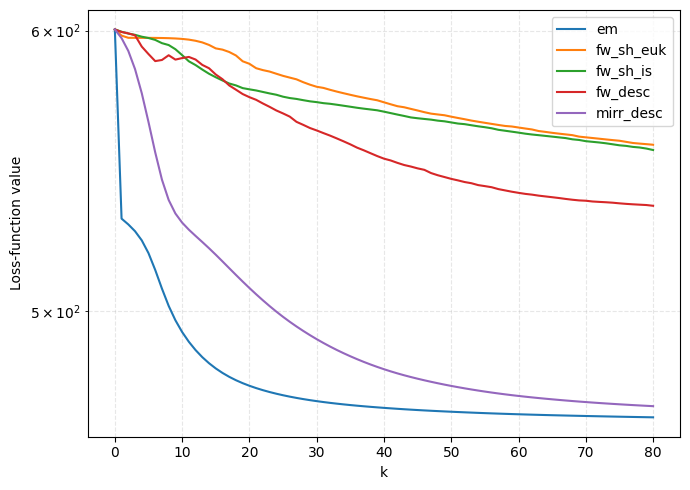

In [17]:
results = {}
for name, path in paths.items():
    if os.path.exists(path["Fs"]):
        results[name] = np.load(path["Fs"])
    else:
        print(f"[warning] Missing cache file: {path}")

fig, ax = plt.subplots(figsize=(7, 5))

for name, Fs in results.items():
    ax.semilogy(Fs / x.shape[1], label=name)

ax.set_xlabel("k")
ax.set_ylabel("Loss-function value")
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('constant_step_MD_6.png')
plt.show()

## Experiments. Enron Emails

Enron Emails:  
orig source: www.cs.cmu.edu/~enron  
D=39861  
W=28102  
N=6,400,000 (approx)    

https://archive.ics.uci.edu/dataset/164/bag+of+words

In [ ]:
x, vocab = load_uci_bow("../enron_dataset/docword.enron.txt", "../enron_dataset/vocab.enron.txt") 
# x, vocab = load_uci_bow("/kaggle/input/enron-emails/docword.enron.txt", "/kaggle/input/enron-emails/vocab.enron.txt") 
sp.save_npz('../docword.enron.npz', x)
np.savez_compressed('../vocab.enron.npz', vocab)

In [19]:
x = sp.load_npz("../docword.enron.npz")
print(f"BoW matrix successfully loaded to {type(x)}")
vocab = np.load('../vocab.enron.npz')
print(f"Vocab successfully loaded to {type(vocab)}")

num_docs, num_terms = x.shape
num_topics = 50
max_iters = 80
verbskip = max_iters / 10

BoW matrix successfully loaded to <class 'scipy.sparse._csr.csr_matrix'>
Vocab successfully loaded to <class 'numpy.lib.npyio.NpzFile'>


In [20]:
rng = np.random.default_rng(42)

# Если инициализировать равномерным распределением, то EM не будет работать!
Phi0 = rng.dirichlet(np.ones(num_terms), size=num_topics).T
Theta0 = rng.dirichlet(np.ones(num_topics), size=num_docs).T

assert Phi0.shape == (num_terms, num_topics)
assert np.allclose(Phi0.sum(axis=0), 1.0, atol=1e-9)

assert Theta0.shape == (num_topics, num_docs)
assert np.allclose(Theta0.sum(axis=0), 1.0, atol=1e-9)

topic_loss = Topic_modeling_loss(x)
reg = Decorrelation_regularizer(num_topics=num_topics, tau=0.01)
lmo = lmo_simplex(radius=1.0)

In [21]:
cache_dir = "cached_results_enron"
os.makedirs(cache_dir, exist_ok=True)

# обязательно запускать перед каждым экспериментом, чтобы код в алгоритме обновился
algs = {
    "em": EM_algorithm,
    "fw_sh_euk": FW_topic_model_alternating,
    "fw_sh_is": FW_topic_model_alternating,
    "fw_desc": FW_desc_topic_model_alternating,
    "mirr_desc": Mirror_descent_on_simplex,
}

def cache_paths(alg_name: str):
    d = os.path.join(cache_dir, alg_name)
    os.makedirs(d, exist_ok=True)
    return {
        "Phi": os.path.join(d, "Phi.npy"),
        "Theta": os.path.join(d, "Theta.npy"),
        "Fs": os.path.join(d, "Fs.npy"),
        "Ts": os.path.join(d, "Ts.npy"),
    }

paths = {name: cache_paths(name) for name in algs.keys()}

results = {}

for alg_name, alg_fn in algs.items():
    p = paths[alg_name]

    cached_available = (
        os.path.exists(p["Phi"])
        and os.path.exists(p["Theta"])
        and os.path.exists(p["Fs"])
        and os.path.exists(p["Ts"])
    )

    if cached_available:
        print(f"[{alg_name}] Loading cached results...")
        results[alg_name] = {
            "Phi": np.load(p["Phi"]),
            "Theta": np.load(p["Theta"]),
            "Fs": np.load(p["Fs"]),
            "Ts": np.load(p["Ts"]),
        }
        continue

    print(f"[{alg_name}] Running algorithm...")

    if alg_name == "em":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            x, Phi0, Theta0, topic_loss, reg,
            maxitrs=max_iters, verbskip=verbskip, name=alg_name
        )
    elif alg_name == "fw_sh_is":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            topic_loss, reg, bregman_itakura_saito,
            Phi0, Theta0,
            maxitrs=max_iters,
            lmo=lmo,
            verbskip=verbskip, name=alg_name
        )
    elif alg_name == "fw_sh_euk":
        continue
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            topic_loss, reg, euklid_distance,
            Phi0, Theta0,
            maxitrs=max_iters,
            lmo=lmo,
            verbskip=verbskip, name=alg_name
        )
    elif alg_name == "fw_desc":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            topic_loss, reg,
            Phi0, Theta0,
            maxitrs=max_iters, 
            lmo=lmo,
            verbskip=verbskip, name=alg_name
        )
    elif alg_name == "mirr_desc":
        Phi_sol, Theta_sol, Fs, Ts = alg_fn(
            x, Phi0, Theta0, topic_loss, reg,
            maxitrs=max_iters, verbskip=verbskip, name=alg_name
        )
    else:
        raise ValueError("Unknown algorithm")

    print(f"[{alg_name}] Saving cache...")
    np.save(p["Phi"], Phi_sol)
    np.save(p["Theta"], Theta_sol)
    np.save(p["Fs"], Fs)
    np.save(p["Ts"], Ts)

    results[alg_name] = {
        "Phi": Phi_sol,
        "Theta": Theta_sol,
        "Fs": Fs,
        "Ts": Ts,
    }

print("All algorithms finished.")

[em] Running algorithm...

em Algorithm
     k        F(x)        time
     0  5.468962e+07    23.9
     8  5.208021e+07   157.7
    16  4.956511e+07   291.8
    24  4.889054e+07   425.7
    32  4.862903e+07   560.3
    40  4.848061e+07   696.0
    48  4.839596e+07   832.3
    56  4.833723e+07   968.2
    64  4.829589e+07  1103.0
    72  4.826459e+07  1237.5
    79  4.824229e+07  1356.8
[em] Saving cache...
[fw_sh_euk] Running algorithm...
[fw_sh_is] Running algorithm...
\nFW algorithm name=fw_sh_is
     k      F(x)         time
     0   6.578e+07     2.2
     1   6.575e+07   116.5
     8   6.542e+07   314.6
    16   6.480e+07   578.0
    24   6.419e+07   833.9
    32   6.376e+07  1100.0
    40   6.343e+07  1363.3
    48   6.310e+07  1618.7
    56   6.284e+07  1880.8
    64   6.254e+07  2141.3
    72   6.223e+07  2402.3
[fw_sh_is] Saving cache...
[fw_desc] Running algorithm...
\nFW algorithm name=fw_desc
     k      F(x)         time
     0   6.578e+07     2.1
     1   6.588e+07    13.

[warning] Missing cache file: {'Phi': 'cached_results_enron/fw_sh_euk/Phi.npy', 'Theta': 'cached_results_enron/fw_sh_euk/Theta.npy', 'Fs': 'cached_results_enron/fw_sh_euk/Fs.npy', 'Ts': 'cached_results_enron/fw_sh_euk/Ts.npy'}


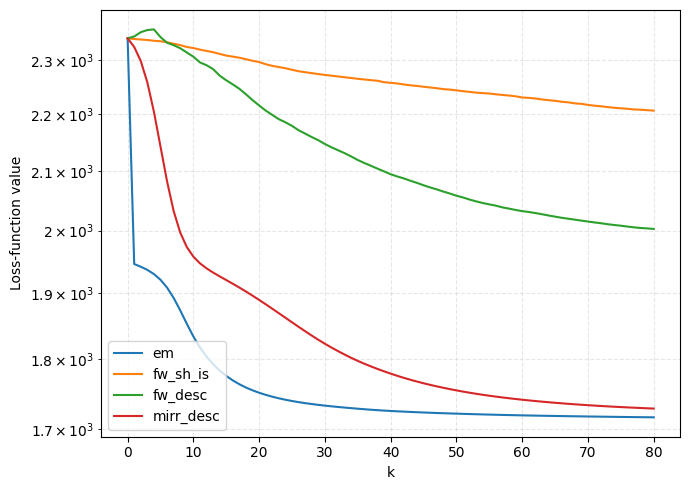

In [22]:
results = {}
for name, path in paths.items():
    if os.path.exists(path["Fs"]):
        results[name] = np.load(path["Fs"])
    else:
        print(f"[warning] Missing cache file: {path}")

fig, ax = plt.subplots(figsize=(7, 5))

for name, Fs in results.items():
    ax.semilogy(Fs / x.shape[1], label=name)

ax.set_xlabel("k")
ax.set_ylabel("Loss-function value")
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('tm_enron_max_cnst_step.png')
plt.show()

## Conclusion

We see that any version of FW method converges are slowler then EM algorithm, although the mirror descend can have almost the same convergence rate as EM.